# Prueba de cobertura del suelo (CORINE)

Este notebook visualiza las nueve proporciones CORINE agregadas a la misma malla de 1 km que el grid y la topografía.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

PROJECT_DIR = Path(r"C:/Users/alfon/PycharmProjects/Sistema-deteccion-incendios")
LANDCOVER_PATH = PROJECT_DIR / "data/processed/landcover_test.nc"
LANDCOVER_VARIABLES = [
    "artificial", "agriculture", "broadleaf_forest",
    "coniferous_forest", "mixed_forest", "scrub",
    "open_spaces", "wetlands", "water",
]

In [2]:
landcover = xr.open_dataset(LANDCOVER_PATH)
display(landcover)

print("Variables:", list(landcover.data_vars))
print(f"Celdas activas: {int(landcover.is_galicia.sum()):,}")

<xarray.Dataset> Size: 2MB
Dimensions:            (y: 225, x: 203)
Coordinates:
  * y                  (y) float64 2kB 2.245e+06 2.246e+06 ... 2.469e+06
  * x                  (x) float64 2kB 2.76e+06 2.761e+06 ... 2.962e+06
Data variables:
    is_galicia         (y, x) uint8 46kB ...
    artificial         (y, x) float32 183kB ...
    agriculture        (y, x) float32 183kB ...
    broadleaf_forest   (y, x) float32 183kB ...
    coniferous_forest  (y, x) float32 183kB ...
    mixed_forest       (y, x) float32 183kB ...
    scrub              (y, x) float32 183kB ...
    open_spaces        (y, x) float32 183kB ...
    wetlands           (y, x) float32 183kB ...
    water              (y, x) float32 183kB ...
Attributes:
    title:               Land cover variables
    description:         CORINE Land Cover fractions aggregated to the 1 km s...
    module:              landcover
    source:              CORINE Land Cover 2018 V2020_20u1
    crs:                 EPSG:3035
    spatial_resolution:  1000 m

Variables: ['is_galicia', 'artificial', 'agriculture', 'broadleaf_forest', 'coniferous_forest', 'mixed_forest', 'scrub', 'open_spaces', 'wetlands', 'water']
Celdas activas: 29,601


In [3]:
fractions = landcover[LANDCOVER_VARIABLES].to_array()
covered = fractions.notnull().any("variable") & landcover.is_galicia.astype(bool)
sum_by_cell = fractions.sum("variable", skipna=True).where(covered)

print(f"Celdas con CORINE válido: {int(covered.sum()):,}")
print(f"Error máximo de cierre: {float(abs(sum_by_cell - 1).max(skipna=True)):.2e}")

means = landcover[LANDCOVER_VARIABLES].mean(dim=("y", "x"), skipna=True).to_pandas()
display(means.sort_values(ascending=False).rename("proporción media").to_frame())

Celdas con CORINE válido: 29,598
Error máximo de cierre: 1.19e-07


,proporción media
agriculture,0.301717
scrub,0.276315
broadleaf_forest,0.234343
coniferous_forest,0.096018
mixed_forest,0.049037
artificial,0.024327
open_spaces,0.010710
water,0.006654
wetlands,0.000879


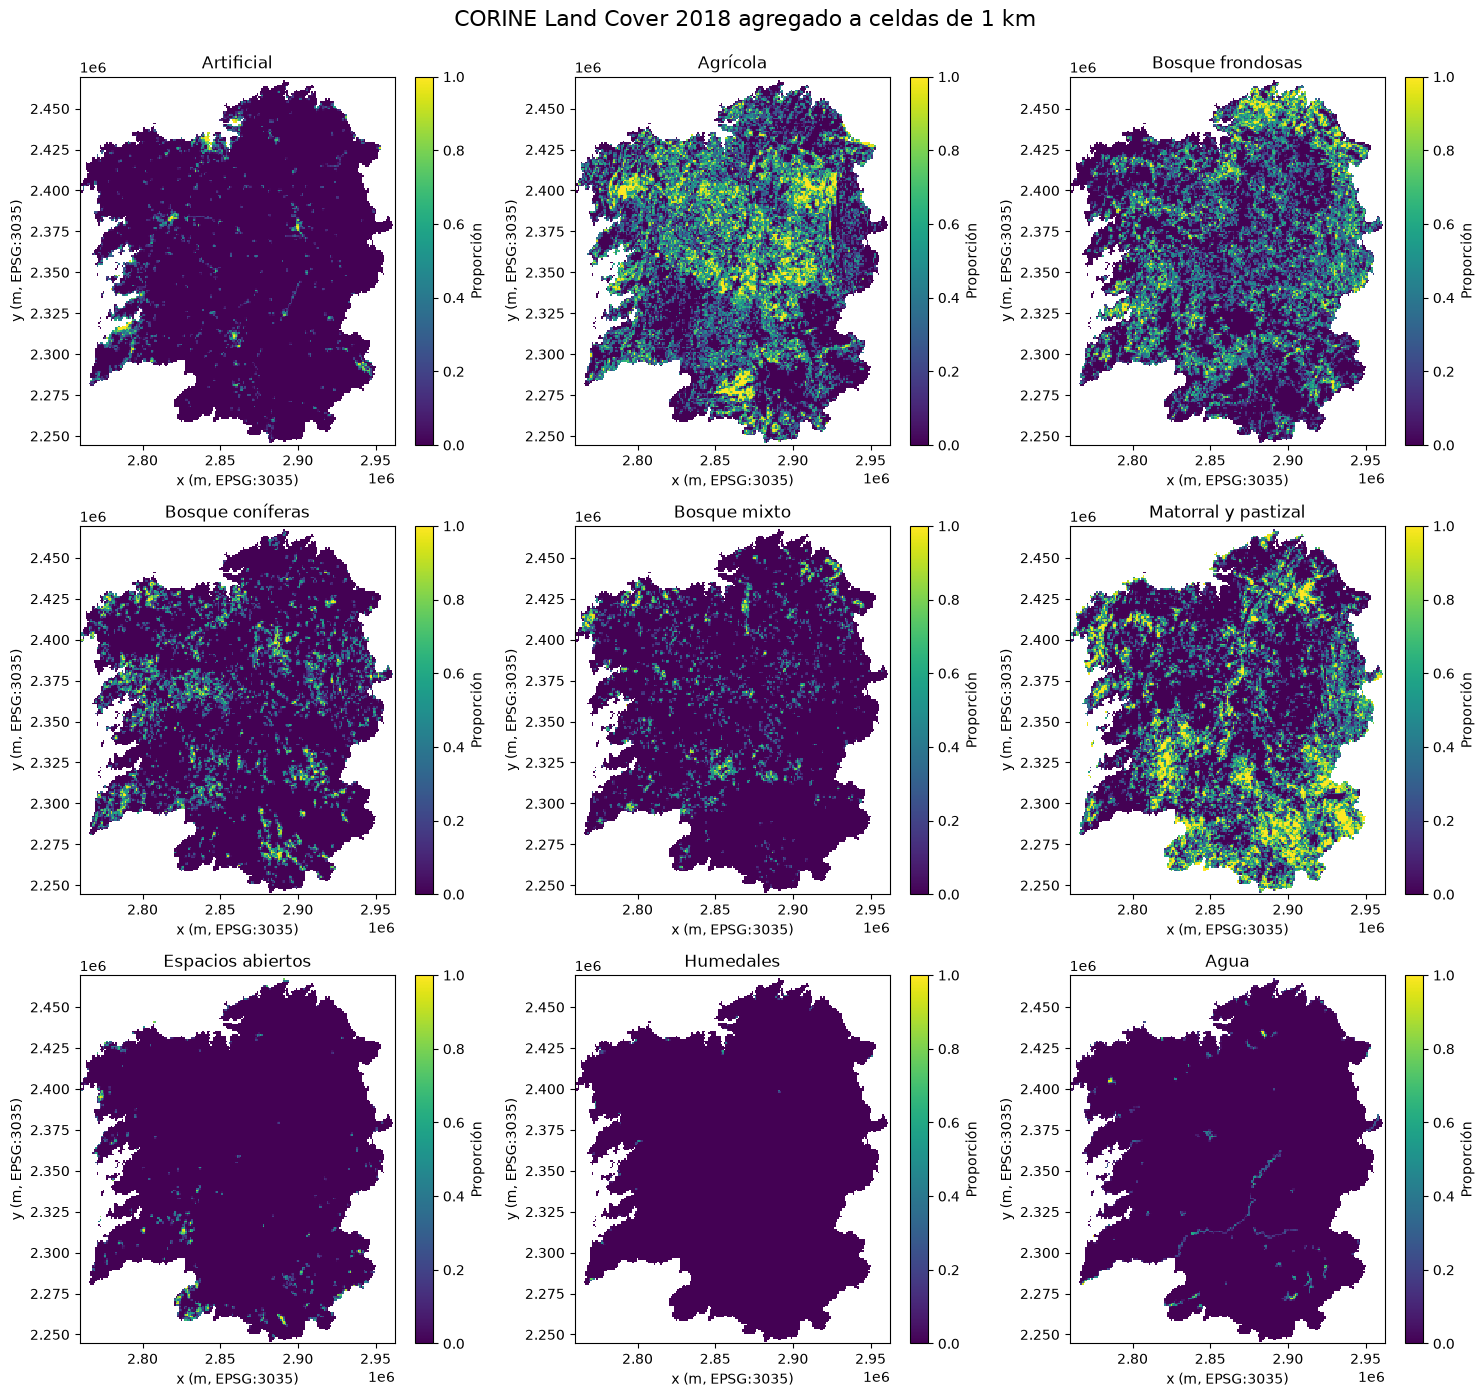

In [4]:
labels = {
    "artificial": "Artificial", "agriculture": "Agrícola",
    "broadleaf_forest": "Bosque frondosas", "coniferous_forest": "Bosque coníferas",
    "mixed_forest": "Bosque mixto", "scrub": "Matorral y pastizal",
    "open_spaces": "Espacios abiertos", "wetlands": "Humedales", "water": "Agua",
}

fig, axes = plt.subplots(3, 3, figsize=(15, 14), facecolor="white")
for ax, variable in zip(axes.flat, LANDCOVER_VARIABLES):
    landcover[variable].where(landcover.is_galicia == 1).plot(
        ax=ax, cmap="viridis", vmin=0, vmax=1, add_colorbar=True,
        cbar_kwargs={"label": "Proporción"},
    )
    ax.set_title(labels[variable])
    ax.set_xlabel("x (m, EPSG:3035)")
    ax.set_ylabel("y (m, EPSG:3035)")

fig.suptitle("CORINE Land Cover 2018 agregado a celdas de 1 km", fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

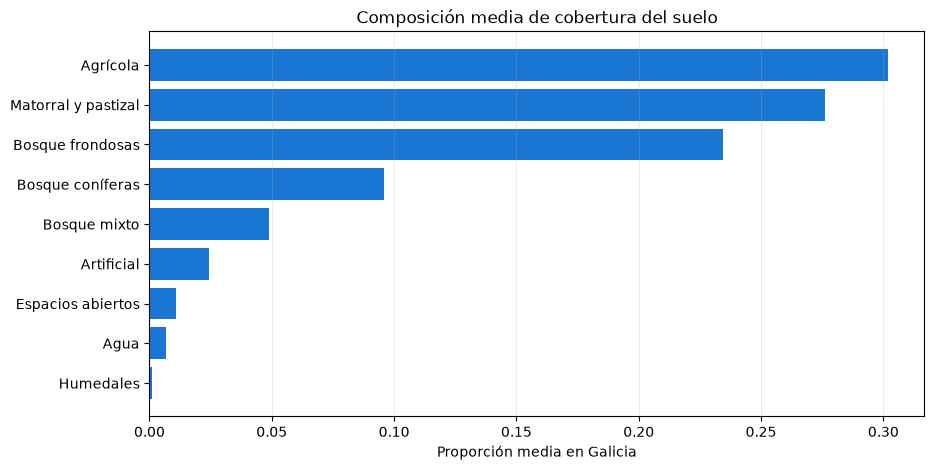

In [5]:
mean_by_class = means.sort_values()
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.barh([labels[name] for name in mean_by_class.index], mean_by_class.values, color="#1976D2")
ax.set_xlabel("Proporción media en Galicia")
ax.set_title("Composición media de cobertura del suelo")
ax.grid(axis="x", alpha=0.25)
plt.show()